In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import uniform, loguniform

from sklearn.datasets import fetch_california_housing

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV,
    SGDRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    ShuffleSplit,
    validation_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    PolynomialFeatures,
    StandardScaler
)

from sklearn.pipeline import Pipeline

In [2]:


np.random.seed(306)
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

Data Loading and Spliting

In [3]:
# fetch dataset
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)

# train-test split
com_train_features, test_features, com_train_labels, test_labels = train_test_split(
features, labels, random_state=42)

# train -- > train + dev split
train_features, dev_features, train_labels, dev_labels = train_test_split(
com_train_features, com_train_labels, random_state=42)

#### Linear Regression with normal Equation

In [4]:
lin_reg_pipeline = Pipeline([
    ("feature_scaling" , StandardScaler()),
    ("lin_reg" , LinearRegression())
])

lin_reg_cross_results = cross_validate(
    lin_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True
)

lin_reg_train_error = -(lin_reg_cross_results["train_score"])
lin_reg_test_error = -(lin_reg_cross_results["test_score"])

#### Linear Regression with SGDRegressor

In [5]:
sgd_reg_pipeline = Pipeline([
    ("feature_scaling" , StandardScaler()),
    ("sgd_reg" , SGDRegressor(
        max_iter=int(np.ceil(
            1e6/com_train_features.shape[0]
        )),
        early_stopping=True,
        eta0=1e-4,
        learning_rate="constant",
        tol=1e-5,
        validation_fraction=0.1,
        n_iter_no_change=5,
        average=10,
        random_state=42
    ))
])

sgd_reg_cv_results = cross_validate(
    sgd_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    return_estimator=True
)

sgd_train_error = -1 * sgd_reg_cv_results['train_score' ]
sgd_test_error = -1 * sgd_reg_cv_results['test_score']

print(f"Train Mean_Error: {sgd_train_error.mean():.3f} and Std_Error: {sgd_train_error.std():.3f}")
print(f"Test Mean_Error: {sgd_test_error.mean():.3f} and Std_Error: {sgd_train_error.std():.3f}")

Train Mean_Error: 0.534 and Std_Error: 0.013
Test Mean_Error: 0.530 and Std_Error: 0.013


#### Polynomial Regression with degree 2

In [6]:
# intrection_only = False (by Default)

poly_reg_pipeline = Pipeline([
    ("polynomial_transformation" , PolynomialFeatures(degree=2)),
    ("standard_scaler" , StandardScaler()),
    ("regressor" , LinearRegression())
])

poly_reg_cv_results = cross_validate(
    poly_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
)

poly_reg_train_score = -(poly_reg_cv_results["train_score"])
poly_reg_test_score = -(poly_reg_cv_results["test_score"])

print(f"Train Mean Error: {poly_reg_train_score.mean():.3f} , Std Error: {poly_reg_train_score.std():.3f}")
print(f"Test Mean Error: {poly_reg_train_score.mean():.3f} , std Error: {poly_reg_train_score.std():.3f}")

Train Mean Error: 0.420 , Std Error: 0.006
Test Mean Error: 0.420 , std Error: 0.006


In [7]:
# intrection_only = True 

poly_reg_pipeline = Pipeline([
    ("polynomial_transformation" , PolynomialFeatures(degree=2 , interaction_only=True)),
    ("standard_scaler" , StandardScaler()),
    ("regressor" , LinearRegression())
])

poly_reg_cv_results = cross_validate(
    poly_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
)

poly_reg_train_score = -(poly_reg_cv_results["train_score"])
poly_reg_test_score = -(poly_reg_cv_results["test_score"])

print(f"Train Mean Error: {poly_reg_train_score.mean():.3f} , Std Error: {poly_reg_train_score.std():.3f}")
print(f"Test Mean Error: {poly_reg_train_score.mean():.3f} , std Error: {poly_reg_train_score.std():.3f}")

Train Mean Error: 0.445 , Std Error: 0.007
Test Mean Error: 0.445 , std Error: 0.007


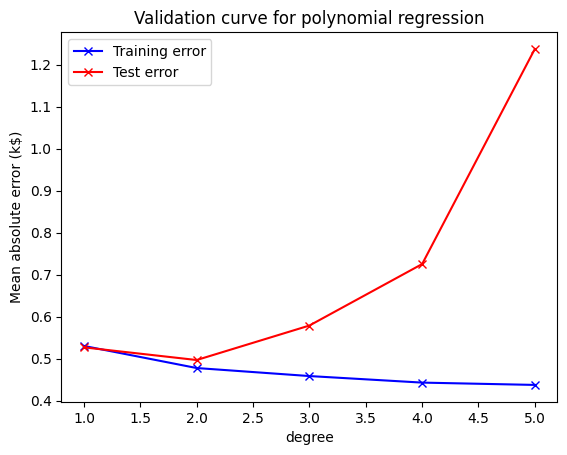

In [8]:
degree = [1, 2, 3, 4, 5]
train_scores, test_scores = validation_curve(
poly_reg_pipeline, com_train_features, com_train_labels, param_name="polynomial_transformation__degree",
param_range=degree, cv=cv, scoring="neg_mean_absolute_error",
n_jobs=2)

train_errors, test_errors = -train_scores, -test_scores
plt.plot(degree, train_errors.mean(axis=1), 'b-x', label="Training error")
plt.plot(degree, test_errors.mean(axis=1), 'r-x', label="Test error")
plt.legend()

plt.xlabel("degree")
plt.ylabel("Mean absolute error (k$)")
_= plt.title("Validation curve for polynomial regression")

#### Ridge Regression

In [9]:
ridge_reg_pipeline = Pipeline([
    ("poly_transformation" , PolynomialFeatures()),
    ("std_scaler" , StandardScaler()),
    ("ridge" , Ridge(alpha=0.5))
])

ridge_cross_cv_results = cross_validate(
    ridge_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True
)

ridge_reg_train_error = -(ridge_cross_cv_results["train_score"])
ridge_reg_test_error = -(ridge_cross_cv_results["test_score"])

print(f"Train Error -> Mean:{ridge_reg_train_error.mean():.3f} , std:{ridge_reg_train_error.std():.3f}")
print(f"Test Error -> Mean:{ridge_reg_test_error.mean():.3f} , std:{ridge_reg_test_error.std():.3f}")

Train Error -> Mean:0.439 , std:0.006
Test Error -> Mean:0.697 , std:0.286


#### Hyperparameter Tuning For Ridge Regression Rate

In [10]:
alpha_list = np.logspace(-4 , 0 , 20)

ridgeCV_pipeline = Pipeline([
    ("polynomial_trnsformation" , PolynomialFeatures(degree=2)),
    ("std_scaler" , StandardScaler()),
    ("ridge" , RidgeCV(
        alphas=alpha_list,
        cv=cv,
        scoring="neg_mean_squared_error"
        ))
])

ridgeCV_pipeline.fit(com_train_features , com_train_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial_trnsformation', ...), ('std_scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [11]:
print("Best Alpha:",ridgeCV_pipeline[-1].alpha_.round(3))
print("Best Score:",-(ridgeCV_pipeline[-1].best_score_.round(3)))

Best Alpha: 0.144
Best Score: 0.652


#### Ridge Hyperparameter tuning with GridSearchCV

In [12]:
ridge_grid_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("feature_scaling", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    'poly__degree': (1, 2, 3),
    'ridge__alpha': np.logspace(-4, 0, num=20)
}
ridge_grid_search = GridSearchCV(
    ridge_grid_pipeline,
    param_grid=param_grid,
    n_jobs=2,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True
)
ridge_grid_search.fit(com_train_features, com_train_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': (1, ...), 'ridge__alpha': array([1.0000...00000000e+00])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",ShuffleSplit(...ain_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [13]:
mean_train_error = -1 * ridge_grid_search.cv_results_['mean_train_score' ] [ridge_grid_search.best_index_]
mean_test_error = -1 * ridge_grid_search.cv_results_[ 'mean_test_score' ] [ridge_grid_search.best_index_]
std_train_error = ridge_grid_search.cv_results_['std_train_score' ] [ridge_grid_search.best_index_]
std_test_error = ridge_grid_search.cv_results_['std_train_score' ] [ridge_grid_search.best_index_]

print(f"Best Mean absolute error of polynomial ridge regression model on the train set:")
print(f"{mean_train_error :.3f} +/- {std_train_error :.3f}")

print(f"Mean absolute error of polynomial ridge regression model on the test set:")
print(f"{mean_test_error :.3f} +/- {std_test_error :.3f}")

Best Mean absolute error of polynomial ridge regression model on the train set:
0.463 +/- 0.004
Mean absolute error of polynomial ridge regression model on the test set:
0.474 +/- 0.004


In [14]:
print ("Mean cross validated score of the best estimator is: ", ridge_grid_search.best_score_)
print ("Mean cross validated error of the best estimator is: ", -ridge_grid_search.best_score_)

Mean cross validated score of the best estimator is:  -0.47386511770034945
Mean cross validated error of the best estimator is:  0.47386511770034945


In [15]:
print ("The best parameter value is:", ridge_grid_search.best_params_)

The best parameter value is: {'poly__degree': 2, 'ridge__alpha': np.float64(0.007847599703514606)}


#### Lasso Regression

In [16]:
lasso_reg_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("feature_scaling", StandardScaler() ),
    ("lasso", Lasso(alpha=0.01 , max_iter=50000 , tol=0.1))
])
lasso_reg_cv_results = cross_validate(
    lasso_reg_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    return_estimator=True
)

lasso_reg_train_error = -1 * lasso_reg_cv_results[ 'train_score' ]
lasso_reg_test_error = -1 * lasso_reg_cv_results[ 'test_score' ]

print(f"Mean absolute error of linear regression model on the train set:\n"
f"{lasso_reg_train_error.mean() :.3f} +/- {ridge_reg_train_error.std( ) :.3f}")
print(f"Mean absolute error of linear regression model on the test set:\n"
f"{lasso_reg_test_error.mean() :.3f} +/- {ridge_reg_test_error.std( ) :.3f}")

Mean absolute error of linear regression model on the train set:
0.533 +/- 0.006
Mean absolute error of linear regression model on the test set:
0.530 +/- 0.286


#### Lasso With GridSearchCV

In [ ]:
lasso_grid_pipeline = Pipeline([
    ("poly", PolynomialFeatures() ),
    ("feature_scaling", StandardScaler()),
    ("lasso", Lasso(tol=0.1 , max_iter=1000))
])

param_grid = {
    'poly__degree': (1, 2, 3),
    'lasso__alpha': np.logspace(-4, 0, num=20)
}

lasso_grid_search = GridSearchCV(
    lasso_grid_pipeline,
    param_grid=param_grid,
    n_jobs=2,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True
)
lasso_grid_search.fit(com_train_features, com_train_labels)

In [ ]:
mean_train_error = -1 * lasso_grid_search.cv_results_[ 'mean_train_score' ] [ lasso_grid_search.best_index_]
mean_test_error = -1 * lasso_grid_search.cv_results_['mean_test_score' ] [lasso_grid_search.best_index_]
std_train_error = lasso_grid_search.cv_results_['std_train_score' ] [lasso_grid_search.best_index_]
std_test_error = lasso_grid_search.cv_results_['std_train_score' ] [lasso_grid_search.best_index_]

print(f"Best Mean absolute error of polynomial ridge regression model on the train set:\n"
f"{mean_train_error :.3f} +/- {std_train_error :.3f}")
print(f"Mean absolute error of polynomial ridge regression model on the test set:\n"
f"{mean_test_error :.3f} +/- {std_test_error :.3f}")


print ("Mean cross validated score of the best estimator is: ", lasso_grid_search.best_score_)
print ("The best parameter value is:", lasso_grid_search.best_params_)

In [ ]:
poly_sgd_pipeline = Pipeline([
    ("poly", PolynomialFeatures()),
    ("feature_scaling", StandardScaler()),
    ("sgd_reg", SGDRegressor(
        penalty='elasticnet',
        random_state=42
    ))
])
poly_sgd_cv_results = cross_validate(
    poly_sgd_pipeline,
    com_train_features,
    com_train_labels,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    return_estimator=True
)

poly_sgd_train_error = -1 * poly_sgd_cv_results['train_score' ]
poly_sgd_test_error = -1 * poly_sgd_cv_results['test_score' ]

print(f"Mean absolute error of linear regression model on the train set: \n"
f"{poly_sgd_train_error.mean() :.3f} +/- {poly_sgd_train_error.std() :.3f}")
print(f"Mean absolute error of linear regression model on the test set:\n"
f"{poly_sgd_test_error.mean() :.3f} +/- {poly_sgd_test_error.std( ) :.3f}")

Mean absolute error of linear regression model on the train set: 
10824283052.546 +/- 4423288211.832
Mean absolute error of linear regression model on the test set:
10946788540.250 +/- 5396536227.703
